In [1]:
!pip -q install git+https://github.com/openai/CLIP.git
!pip -q install ftfy regex tqdm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00


In [2]:
import torch
import clip
import requests
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from io import BytesIO

In [3]:
def show_image(img, title=None, figsize=(4,4)):
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

def load_image_from_url(url: str) -> Image.Image:
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return Image.open(BytesIO(r.content)).convert("RGB")

def l2_normalize(x: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    return x / (x.norm(dim=-1, keepdim=True) + eps)

def cosine_sim(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """
    a: [D] or [1,D]
    b: [N,D]
    returns: [N]
    """
    if a.dim() == 1:
        a = a.unsqueeze(0)  # [1,D]
    a = l2_normalize(a)
    b = l2_normalize(b)
    return (a @ b.T).squeeze(0)  # [N]

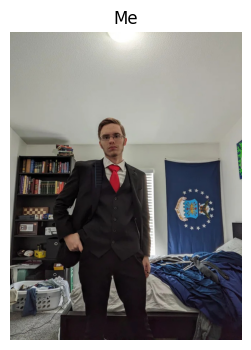

In [4]:
img1 = Image.open("me_no_hat.jpeg").convert("RGB")
show_image(img1, title="Me")

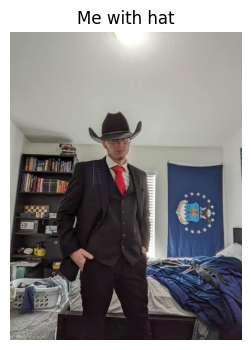

In [5]:
img2 = Image.open("me_with_hat.jpeg").convert("RGB")
show_image(img2, title="Me with hat")

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

with torch.no_grad():
    image_input_1 = preprocess(img1).unsqueeze(0).to(device)
    image_input_2 = preprocess(img2).unsqueeze(0).to(device)

    img_feat_1 = model.encode_image(image_input_1).float()  # [1, D]
    img_feat_2 = model.encode_image(image_input_2).float()  # [1, D]

# Normalize image embeddings for cosine similarity
img_feat_1 = l2_normalize(img_feat_1).squeeze(0)  # [D]
img_feat_2 = l2_normalize(img_feat_2).squeeze(0)  # [D]

print("Image embedding shape:", img_feat_1.shape)

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 174MiB/s]


Image embedding shape: torch.Size([512])


In [7]:
delta = img_feat_2 - img_feat_1
delta = l2_normalize(delta)

words = ["hat", "cup", "cat", "boat"]
with torch.no_grad():
    text_tokens = clip.tokenize(words).to(device)
    text_feats = model.encode_text(text_tokens).float()

text_feats = l2_normalize(text_feats)  # [N, D]
sims = cosine_sim(delta, text_feats).detach().cpu().numpy()

# Optional: apply a temperature / logit scale (CLIP commonly uses a higher scale)
logit_scale = 10.0
logits = logit_scale * sims
probs = np.exp(logits - logits.max())
probs = probs / probs.sum()

# Display results
for w, s, p in sorted(zip(words, sims, probs), key=lambda t: t[2], reverse=True):
    print(f"{w:>5s} | cosine_sim={s:+.4f} | prob={p:.4f}")

  hat | cosine_sim=+0.0794 | prob=0.5129
 boat | cosine_sim=-0.0188 | prob=0.1922
  cup | cosine_sim=-0.0425 | prob=0.1516
  cat | cosine_sim=-0.0481 | prob=0.1433


In [10]:
# Save results to log file

log_file = "clip_test_log.txt"

results = sorted(
    zip(words, sims, probs),
    key=lambda t: t[2],
    reverse=True
)

with open(log_file, "w", encoding="utf-8") as f:
    f.write("=" * 60 + "\n")
    f.write("CLIP TEST RESULTS\n")
    f.write("=" * 60 + "\n\n")

    for w, s, p in results:
        f.write(
            f"{w:>5s} | cosine_sim={s:+.4f} | prob={p:.4f}\n"
        )

print(f"Log saved to: {log_file}")

Log saved to: clip_test_log.txt


In [13]:
img_feat = l2_normalize(img_feat_2)

words = ["hat", "cup", "cat", "boat"]

with torch.no_grad():
    text_tokens = clip.tokenize(words).to(device)
    text_feats = model.encode_text(text_tokens).float()

text_feats = l2_normalize(text_feats)

sims = cosine_sim(img_feat, text_feats).detach().cpu().numpy()

# Optional: apply a temperature / logit scale (CLIP commonly uses a higher scale)
logit_scale = 10.0
logits = logit_scale * sims
probs = np.exp(logits - logits.max())
probs = probs / probs.sum()

# Display results
for w, s, p in sorted(zip(words, sims, probs), key=lambda t: t[2], reverse=True):
    print(f"{w:>5s} | cosine_sim={s:+.4f} | prob={p:.4f}")

  hat | cosine_sim=+0.2487 | prob=0.3738
  cup | cosine_sim=+0.1928 | prob=0.2137
 boat | cosine_sim=+0.1915 | prob=0.2111
  cat | cosine_sim=+0.1869 | prob=0.2014


In [14]:
# Save results to log file

log_file = "clip_test_log_2.txt"

results = sorted(
    zip(words, sims, probs),
    key=lambda t: t[2],
    reverse=True
)

with open(log_file, "w", encoding="utf-8") as f:
    f.write("=" * 60 + "\n")
    f.write("CLIP TEST RESULTS 2\n")
    f.write("=" * 60 + "\n\n")

    for w, s, p in results:
        f.write(
            f"{w:>5s} | cosine_sim={s:+.4f} | prob={p:.4f}\n"
        )

print(f"Log saved to: {log_file}")

Log saved to: clip_test_log_2.txt


In [ ]:
import torch
norm = torch.linalg.norm(img_feat_1, ord=2)
torch.allclose(norm, torch.ones_like(norm))

True

# Conclusion

Natural Language supervision allows the image encoder to create rich vectors that better encode the meaning of the image.